### Autors

Ziyi Hong - *2694933*

Danylo Tulainov - *5070969*

# Laborarbeit - Teil 2

## Ausgangssituation

Sie arbeiten im Data-Science-Team eines Unternehmens mit internem IT-Support.

Die Support-Leitung möchte eingehende Tickets automatisch danach einstufen, ob sie niedrige oder hohe Priorität haben. Ziel ist es, kritische Tickets schneller zu erkennen und zeitnah zu bearbeiten.

Die Fachabteilung stellt dabei zwei Anforderungen:

1. Das Verfahren soll einfach und nachvollziehbar sein.
2. Es soll möglich sein, für beide Klassen (niedrige Priorität/hohe Priorität) die wichtigsten Signalwörter anzugeben, also Wörter, die eher für hohe bzw. niedrige Priorität sprechen.

Außerdem steht nur ein relativ kleiner Datensatz zur Verfügung. Die Support-Leitung bevorzugt daher ein Verfahren, das auch bei begrenzter Datenmenge stabil einsetzbar ist.

## Datensatz

Sie erhalten den Datensatz `support_tickets_synthetisch_200.csv`.
Die Datei enthält die folgenden Spalten:

- `ticket_id`: eindeutige Ticket-ID
- `subject`: Betreff des Tickets
- `message`: eigentliche Ticketbeschreibung
- `priority`: Zielvariable mit den Klassen `hoch` und `niedrig`

## Aufgabe

**Ihre Aufgabe ist es auf Basis dieser Anforderungen eine Lösung für das Support-Team zu entwickeln.**

## Hinweise

Die Aufgabenstellung ist bewusst offen gehalten. Berücksichtigen Sie bei der Bearbeitung der Aufgabe die folgenden Hinweise:
* Dokumentieren Sie Ihr Vorgehen strukturiert und nachvollziehbar.
* Begründen Sie Ihre Vorgehensweise und Entscheidungen.
* Interpretieren Sie Ergebnisse.
* Erstellen Sie, wo möglich und sinnvoll, Plots.
* **Nutzen Sie nur Methoden, Konzepte und Begründungen, die in der Vorlesung behandelt wurden. Falls dies nicht möglich ist, begründen Sie warum.**
* Identifizieren Sie Schwachstellen/Limitationen Ihrer Arbeit und erläutern Sie diese auf Basis der Vorlesungsinhalte.

Berücksichtigen Sie die folgenden Hinweise für die Abgabe:
* Arbeiten Sie in 2er-Gruppen und geben Sie je Gruppe ein Notebook ab.
* Nennen Sie im abgegebenen Notebook die Gruppenmitglieder.
* **Für die Verwendung von KI berücksichtigen Sie die Hinweise von Herrn Prof. Hänisch.**
* Die erste Abgabe muss am Dienstag, den 17.03., zwischen 15:30 und 16:15 Uhr per Moodle erfolgen.
* Die endgültige Abgabe muss bis Dienstag, den 24.03., um 23:59 Uhr per Moodle erfolgen.
* Gewertet wird die endgültige Abgabe. Wenn Sie zwischen erster und endgültiger Abgabe Änderungen vornehmen, müssen Sie diese begründen.

## Business Understanding

The first stage of **CRISP-DM**.

The goal of this task is to automate the classification of internal IT support tickets into high and low priority categories. The support team requires a simple, transparent model that works stably on a small dataset and can extract *signal words* that influence the classification decisions.

Transparent means: *we dont want black box model*.


## Data understanding and Data Preparation

According to **CRISP-DM** the next step is *Data Understanding*. This is combined with *Data Preparation* in this task, since the second one consists only of one step.

At this stage the following steps are taken:
- Load of dataset
- Combine text features into one
- Store the target feature to `y` and training features to `X`
- Feature engineering:
    - Find the unique categories per target feature
    - Outline top features
- Train-test-split

#### Import packages

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [3]:
# Load the dataset
df = pd.read_csv('support-dataset.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ticket_id  200 non-null    object
 1   subject    200 non-null    object
 2   message    200 non-null    object
 3   priority   200 non-null    object
dtypes: object(4)
memory usage: 6.4+ KB


In [4]:
df.head()

,ticket_id,subject,message,priority
0,TKT-0039,Sicherheitsvorfall in Dateiserver,Es besteht der Verdacht auf einen Sicherheitsv...,niedrig
1,TKT-0134,Später umsetzen: Export nach Excel in SAP,Die Anpassung Export nach Excel in SAP wäre hi...,hoch
2,TKT-0070,Verdacht auf Datenverlust in E-Mail,In E-Mail fehlen seit 45 Minuten Datensätze. E...,hoch
3,TKT-0192,Wunsch: Dark Mode in Citrix,"Für Produktion besteht der Wunsch, in Citrix D...",niedrig
4,TKT-0018,Produktionsstillstand wegen Problemen mit Intr...,Durch Probleme mit Intranet besteht Produktion...,hoch


subject, message are for field 'text'
priority is like the 'label'.

#### Define target and training variables

It was decided to combine features `subject` and `message` to maximize context. They are stored in `X`.

In [5]:
y = df['priority']

df['text'] = df['subject'] + ' ' + df['message']
X = df['text']

X.shape

(200,)

In [6]:
y.shape

(200,)

#### Check the unique values in `y`

In [7]:
y.value_counts()

priority
niedrig    100
hoch       100
Name: count, dtype: int64

#### We chose Naive Bayes

Since there are only 2 unique values - which are 'hoch' and 'niedrig' it was decided that the **Naive Bayes** approach is the most suitable for this task. The dataset is small - only 200 entries.

**Naive Bayes** directly calculates the conditional probabilities of individual words, that satisfies the transparency and word extraction requirements. Moreover, it remains stable with limited training data.

#### Train-test-split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)
print(y_test.shape)
print(y_train.shape)

(160,)
(40,)
(40,)
(160,)


## Modeling

The next stage is *Modeling*. Here following logic is done:
- Model evaluation
- Model training

#### Model training

The first training of the model is made using a `Pipeline` to streamline the execution. Text features are transformed directly inside the pipeline.

In [9]:
nb_model = Pipeline([
    ("vec", CountVectorizer(lowercase=True)),
    ("clf", MultinomialNB(alpha=1.0))
])

nb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vec', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## Evaluation

The last stage of **CRISP-DM** is *Evaluation*. At this stage:
- the model's predictions are calculated
- the top features are found

In [10]:
y_pred = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


To ensure that `accuracy_score`'s result was correct, the `classification_report` is used.

`classification_report` provides detailed information of the model's performance for each class, which are in this task 'hoch' and 'niedrig'.

In [11]:
print("Classification report's results:")
print(classification_report(y_test, y_pred))

Classification report's results:
              precision    recall  f1-score   support

        hoch       1.00      1.00      1.00        20
     niedrig       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



#### Find the top features

This step is essential to check whether each feature belongs to 'hoch' or 'niedrig' priority classes.

This shows exactly which words trigger which class makes the model transparent, which helps with interpretation of results.

In [12]:
vectorizer = nb_model.named_steps['vec']
clf = nb_model.named_steps['clf']

feature_names = vectorizer.get_feature_names_out()
class_labels = clf.classes_.tolist()
hoch = class_labels.index('hoch')
niedrig = class_labels.index('niedrig')

#### Extract log probabilities

In [13]:
log_prob_hoch = clf.feature_log_prob_[hoch]
log_prob_niedrig = clf.feature_log_prob_[niedrig]

# here is calculated importance score
importance_score = log_prob_hoch - log_prob_niedrig

In [14]:
signal_words_df = pd.DataFrame({
    'word': feature_names,
    'score': importance_score
})

top_words_hoch = signal_words_df.sort_values(by='score', ascending=False).head(10)
top_words_niedrig = signal_words_df.sort_values(by='score', ascending=True).head(10)

print("\nTop Signal Words for Priority: HOCH")
display(top_words_hoch)
print("\nTop Signal Words for Priority: NIEDRIG")
display(top_words_niedrig)


Top Signal Words for Priority: HOCH


,word,score
159,mehr,3.541289
211,seit,3.325066
266,wodurch,3.289975
147,können,3.289975
56,blockiert,3.289975
248,verhindert,3.002293
7,aktuell,2.953503
25,aus,2.953503
274,zugriff,2.902210
66,datenverlust,2.902210



Top Signal Words for Priority: NIEDRIG


,word,score
61,das,-4.031214
239,um,-3.300326
233,thema,-3.261105
175,nachrangig,-3.220283
88,empfehlung,-3.086752
183,nutzung,-3.086752
277,zur,-3.086752
188,optimierung,-2.986668
181,nur,-2.932601
244,verbesserung,-2.875443


#### Plot the results

The top signal words are plotted

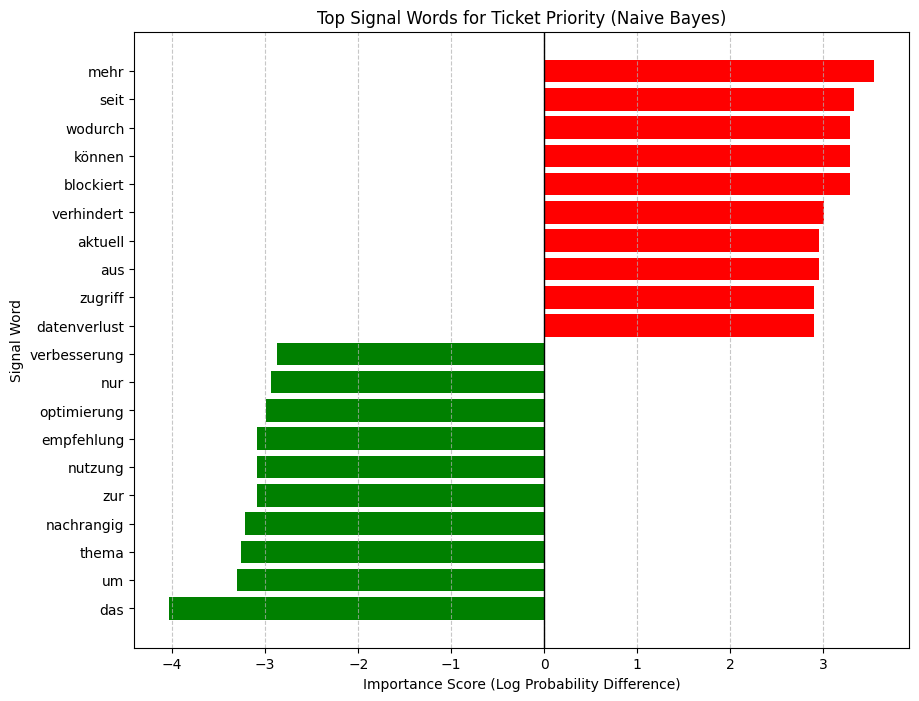

In [15]:
plot_df = pd.concat([top_words_hoch, top_words_niedrig]).sort_values(by='score')

plt.figure(figsize=(10, 8))
colors = ['green' if score < 0 else 'red' for score in plot_df['score']]
plt.barh(plot_df['word'], plot_df['score'], color=colors)
plt.title('Top Signal Words for Ticket Priority (Naive Bayes)')
plt.xlabel('Importance Score (Log Probability Difference)')
plt.ylabel('Signal Word')
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Limitation


The *Naive Bayes* approach works perfectly well for this specific task, but it has distinct limitations. Based on the approach itself.

Firstly, the *Naive Bayes* algorithm assumes all features (which are words in this task) are completely independent of one another.

Another limitation lays in `CountVectorizer`. It creates a *Bag of Words*, meaning the model ignores the syntax, grammar and order of words.

Consequently, the model struggles with negations. For instance, if word 'emergency' ('Notfall') is learned as a strong signal for high priority, the phrase 'no emergency' ('kein Notfall') can be misclassified as high priority, because the model processes 'no' ('kein') and 'emergency' ('Notfall') independently.

Another limitation is the **size of the dataset**. *Naive Bayes* is generally robust on small datasets compared to complex algorithms like *Neural Networks*, however the limited vocabulary size means the model might struggle if future tickets contain entirely new terminology or slang what was not present in the training dataset's vocabulary.

# The second approach: keine Pipeline

Provide more transparency comparing to use pipeline

In [16]:
import nltk
from nltk.tokenize import word_tokenize
import string
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /Users/hong/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Data preparation
use nltk package to tokenize the text

In [17]:
print(X_train.head())
print(y_train.head())
y_train.value_counts()


115    Produktionsstillstand wegen Problemen mit Netz...
146    Empfehlung zur Nutzung von Intranet Wir bitten...
162    Produktionsstillstand wegen Problemen mit Netz...
0      Sicherheitsvorfall in Dateiserver Es besteht d...
109    Optional: Startseiten-Anpassung für SAP Die Fu...
Name: text, dtype: object
115       hoch
146    niedrig
162       hoch
0      niedrig
109    niedrig
Name: priority, dtype: object


priority
hoch       80
niedrig    80
Name: count, dtype: int64

In [18]:
# preprocess the text
def preprocess(text):
    # small case 
    text = text.lower()
    # tokenize the text
    tokens = word_tokenize(text)
    # remove the punctuation
    tokens = [
        token for token in tokens
        if token not in string.punctuation
    ]
    return tokens
X_train_tokens = X_train.apply(preprocess)
X_test_tokens = X_test.apply(preprocess)


In [19]:
X.head()

0    Sicherheitsvorfall in Dateiserver Es besteht d...
1    Später umsetzen: Export nach Excel in SAP Die ...
2    Verdacht auf Datenverlust in E-Mail In E-Mail ...
3    Wunsch: Dark Mode in Citrix Für Produktion bes...
4    Produktionsstillstand wegen Problemen mit Intr...
Name: text, dtype: object

In [20]:
X_train_tokens.head()

115    [produktionsstillstand, wegen, problemen, mit,...
146    [empfehlung, zur, nutzung, von, intranet, wir,...
162    [produktionsstillstand, wegen, problemen, mit,...
0      [sicherheitsvorfall, in, dateiserver, es, best...
109    [optional, startseiten-anpassung, für, sap, di...
Name: text, dtype: object

In [21]:
def create_freq_table(token_lists, labels):
    result = {}
    for tokens, y in zip(token_lists, labels):
        for word in tokens:
            pair = (word, y)
            if pair in result.keys():
                result[pair] += 1
            else:
                result[pair] = 1
    return result

freq_table = create_freq_table(X_train_tokens, y_train)
for pair in list(freq_table.items())[:10]:
    print(pair)

                

(('produktionsstillstand', 'hoch'), 16)
(('wegen', 'hoch'), 8)
(('problemen', 'hoch'), 8)
(('mit', 'hoch'), 16)
(('netzlaufwerk', 'hoch'), 10)
(('durch', 'hoch'), 8)
(('probleme', 'hoch'), 17)
(('besteht', 'hoch'), 23)
(('der', 'hoch'), 66)
(('prozess', 'hoch'), 8)


In [22]:
# lookup function
def lookup(freq, word, label):
    n = 0
    pair = (word, label)
    if pair in freq:
        n = freq[pair]
    return n


In [23]:
lookup(freq_table, 'dringend', 'hoch')


18

In [24]:
lookup(freq_table, 'nicht', 'niedrig')

16

## Modeling

In [25]:
import numpy as np
def train_naive_bayes(freq_table, train_y):
    loglikelihood = {}
    logprior = 0

    vocab = set([pair[0] for pair in freq_table.keys()])
    n = len(vocab)
    
    N_hoch = N_nied = 0
    for pair in freq_table.keys():
        if pair[1] == 'hoch':
            N_hoch += freq_table[pair]
        else:
            N_nied += freq_table[pair]
            
    D = len(train_y)
    D_hoch = len([y for y in train_y if y == 'hoch'])
    D_nied = D - D_hoch

    logprior = np.log(D_hoch) - np.log(D_nied)

    for word in vocab:
        freq_hoch = lookup(freq_table, word, 'hoch')
        freq_nied = lookup(freq_table, word, 'niedrig')

        # conditional probability of the word given the class
        # Laplace smoothing
        p_w_hoch = (freq_hoch + 1) / (N_hoch + n)
        p_w_nied = (freq_nied + 1) / (N_nied + n)

        loglikelihood[word] = np.log(p_w_hoch / p_w_nied)

    return logprior, loglikelihood


    

In [26]:
logprior, loglikelihood = train_naive_bayes(freq_table, y_train)

print(logprior) # log prior is 0 because hoch number = niedrig number
print(len(loglikelihood))

0.0
273


## Inference and Evaluation

In [27]:
def naive_bayes_predict(text, logprior, loglikelihood):
    tokens = preprocess(text)
    p = 0
    p += logprior
    
    for word in tokens:
        if word in loglikelihood:
            p += loglikelihood[word]
    return p

In [28]:
# pred label using naive_bayes_predict
# if pred_lab == true_lab, correct += 1
def accuracy(X_test_tokens, y_test, logprior, loglikelihood):
    correct = 0
    for text, true_label in zip(X_test_tokens, y_test):
        if naive_bayes_predict(" ".join(text), logprior, loglikelihood) > 0:
            predicted_label = "hoch"
        else:
            predicted_label = "niedrig"
        
        if predicted_label == true_label:
            correct += 1
    return correct / len(y_test)

# evaluation using test set
print(f"Accuracy: {accuracy(X_test_tokens, y_test, logprior, loglikelihood)}")

Accuracy: 1.0


## evaluation using test_text

write test text to see if the model will predict correctly

In [29]:
test_text_1 = 'Dashboard funktioniert nicht. Bitte dringend beheben.'

# should be hoch

In [30]:
p = naive_bayes_predict(test_text_1, logprior, loglikelihood)
print(p)

priority_1 = "hoch" if p > 0 else "niedrig"
print(f"The priotity from \"{test_text_1}\" is {priority_1} (p={p:.2f}).")



2.4574157440473874
The priotity from "Dashboard funktioniert nicht. Bitte dringend beheben." is hoch (p=2.46).


In [31]:
test_text_2 = 'Anfrage zur Optimierung der Performance. Das Ticket ist nicht dringend.'
# should be niedrig

In [32]:
p = naive_bayes_predict(test_text_2, logprior, loglikelihood)
print(p)

priority_2 = "hoch" if p > 0 else "niedrig"
print(f"The priotity from \"{test_text_2}\" is {priority_2} (p={p:.2f}).")

-12.349968050305867
The priotity from "Anfrage zur Optimierung der Performance. Das Ticket ist nicht dringend." is niedrig (p=-12.35).


In [33]:
test_text_3 = 'Dashboard Monitoring ist nicht verfügbar. Das Ticket ist dringend.'
# should be hoch

In [34]:
p = naive_bayes_predict(test_text_3, logprior, loglikelihood)
print(p)

priority_3 = "hoch" if p > 0 else "niedrig"
print(f"The priotity from \"{test_text_3}\" is {priority_3} (p={p:.2f}).")

# false prediction

-2.575975756539539
The priotity from "Dashboard Monitoring ist nicht verfügbar. Das Ticket ist dringend." is niedrig (p=-2.58).


In [35]:
tokens = preprocess(test_text_3)
for word in tokens:
    if word in loglikelihood:
        score = loglikelihood[word]
        direction = "hoch" if score > 0 else "niedrig"
        print(f"{word:<20} {score:+.2f}  → {direction}")
    else:
        print(f"{word:<20}  not in vocabulary")
p = sum(loglikelihood.get(w, 0) for w in tokens) + logprior
print(f"\nTotal p = {p:.2f}  → {'hoch' if p > 0 else 'niedrig'}")

dashboard             not in vocabulary
monitoring           +0.18  → hoch
ist                  +0.05  → hoch
nicht                +1.44  → hoch
verfügbar            +1.87  → hoch
das                  -4.06  → niedrig
ticket               -2.90  → niedrig
ist                  +0.05  → hoch
dringend             +0.79  → hoch

Total p = -2.58  → niedrig


The prediction is **wrong**. Although the text contains urgency words like *dringend*
, the words `das` (score: −4.06) and `ticket` (score: −2.91) are the reason why the result it `niedrig`, even though they are actually neutral words.

These words appear very often in low-priority tickets in the training data, so the model learned to associate them with `niedrig`.

This shows a key weakness of Naive Bayes:
it cannot distinguish between important words and unimportant filler words.

some new texts that are not in the dataset

In [36]:
text_examples = [
    "Das System läuft nicht. Sofortiger Handlungsbedarf!",
    "Server abgestürzt. Bitte schnellstmöglich beheben.",
    "Kritischer Fehler – System reagiert nicht mehr.",
    "Wunsch: Dark Mode in Microsoft Teams einrichten.",
    "Später umsetzen: zusätzlicher Report in Dashboard wäre hilfreich.",
]

label_examples = [
    "hoch",
    "hoch",
    "hoch",
    "niedrig",
    "niedrig",
]

text_tokens = [preprocess(text) for text in text_examples]

acc = accuracy(text_tokens, label_examples, logprior, loglikelihood)
print(f"New texts accuracy: {acc}")


New texts accuracy: 0.8


# Comparison and conclusion

Both implementations achieve identical accuracy of 100% on the test set. 
But without using pipeline, the solution privide more transparency.

## Limitation: 

The model can only assign probability scores to words that appeared in the training set vocab. The unknown words will be ignored

Naive Bayes:
it cannot distinguish between important words and unimportant filler words. Vocab is fully based on the training data. 

## Solution: 

We can skip those stop words (remove 'das', 'ist', 'nicht').

Train it on a bigger dataset.

# Third Approach: Support Vector Machine (without Pipeline)

As an alternative to Naive Bayes, a Support Vector Machine (SVM) is implemented here.
The goal is to compare the two approaches and offer a second method for the team to choose.

Like in the second approach, no `Pipeline` is used. 

## Data Preparation

The text data cannot be passed directly to an SVM.
`CountVectorizer` is used to transform each ticket text into a word count vector.

It is fitted **only on the training set**, then applied to the test set.

In [37]:
from sklearn.feature_extraction.text import CountVectorizer

svm_vectorizer = CountVectorizer(lowercase=True)
X_train_svm = svm_vectorizer.fit_transform(X_train)
X_test_svm  = svm_vectorizer.transform(X_test)

print("Vocabulary size:", len(svm_vectorizer.vocabulary_))
print("X_train_svm shape:", X_train_svm.shape)
print("X_test_svm shape :", X_test_svm.shape)

Vocabulary size: 280
X_train_svm shape: (160, 280)
X_test_svm shape : (40, 280)


#### Feature Scaling

As used in the SVM lecture, a `StandardScaler` is applied before training.

In [44]:
from sklearn.preprocessing import StandardScaler

svm_scaler = StandardScaler(with_mean=False)

X_train_svm_scaled = svm_scaler.fit_transform(X_train_svm)
X_test_svm_scaled  = svm_scaler.transform(X_test_svm)

## Modeling

`LinearSVC` is used here.

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(C=1.0, random_state=42)

svm_model.fit(X_train_svm_scaled, y_train)

/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

## Inference and Evaluation

In [45]:
y_pred_svm = svm_model.predict(X_test_svm_scaled)

print("Train accuracy:", accuracy_score(y_train, svm_model.predict(X_train_svm_scaled)))
print("Test accuracy :", accuracy_score(y_test, y_pred_svm))
print()
print(classification_report(y_test, y_pred_svm))

Train accuracy: 1.0
Test accuracy : 1.0

              precision    recall  f1-score   support

        hoch       1.00      1.00      1.00        20
     niedrig       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [46]:
import pandas as pd

feature_names_svm = svm_vectorizer.get_feature_names_out()
coef = svm_model.coef_[0]  # one weight per word

svm_words_df = pd.DataFrame({
    'word': feature_names_svm,
    'weight': coef
})

top_svm_hoch    = svm_words_df.sort_values('weight', ascending=False).head(10)
top_svm_niedrig = svm_words_df.sort_values('weight', ascending=True).head(10)

print("Top Signal Words for Priority: hoch")
display(top_svm_hoch)
print("\nTop Signal Words for Priority: niedrig")
display(top_svm_niedrig)

Top Signal Words for Priority: hoch


,word,weight
63,dateiserver,0.344992
61,das,0.073559
80,eine,0.070994
233,thema,0.060746
205,report,0.053087
279,zusätzlicher,0.053087
234,ticket,0.051600
58,crm,0.047555
67,den,0.046757
148,laufenden,0.046757



Top Signal Words for Priority: niedrig


,word,weight
235,ticketsystem,-0.135316
207,sap,-0.125455
154,mail,-0.124014
168,monitoring,-0.116480
159,mehr,-0.064918
15,anmeldung,-0.058163
147,können,-0.056723
174,nach,-0.055095
98,export,-0.055095
97,excel,-0.055095


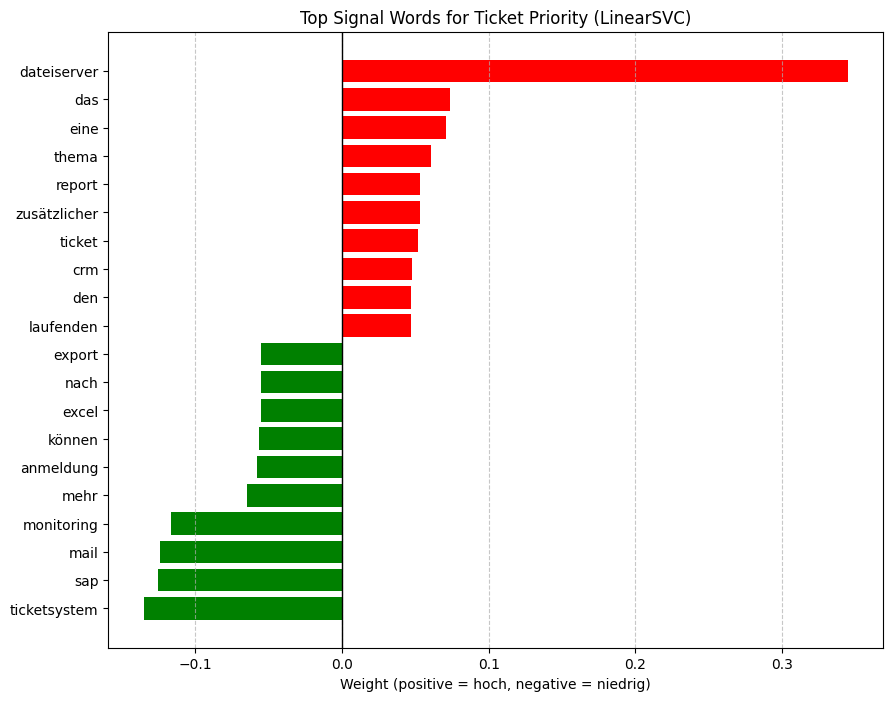

In [47]:
plot_svm = pd.concat([top_svm_hoch, top_svm_niedrig]).sort_values('weight')

plt.figure(figsize=(10, 8))
colors = ['green' if w < 0 else 'red' for w in plot_svm['weight']]
plt.barh(plot_svm['word'], plot_svm['weight'], color=colors)
plt.title('Top Signal Words for Ticket Priority (LinearSVC)')
plt.xlabel('Weight (positive = hoch, negative = niedrig)')
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Comparison: Naive Bayes vs. SVM

| | Naive Bayes (sklearn) | Naive Bayes (manual) | SVM (LinearSVC) |
|---|---|---|---|
| **Test Accuracy** | 1.0 | 1.0 | 1.0 |
| **Signal words** | log probability | log likelihood | coef_ weights |
| **Pipeline used** | Yes | No | No |

All three approaches reach 100% accuracy on this dataset.
